<a href="https://colab.research.google.com/github/sarahibadi/Adult_Census-/blob/main/sxi210032_HW_2_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


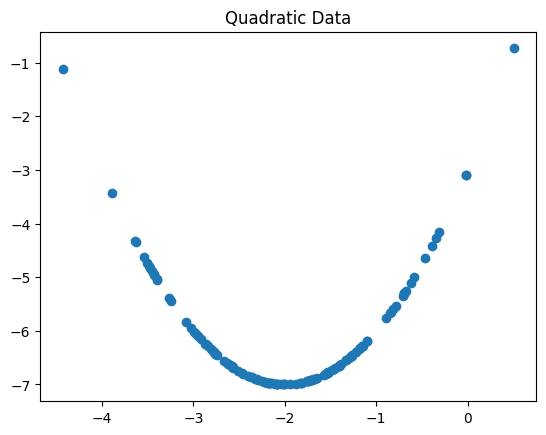


Training 0H model on quadratic data:
Epoch 100 loss: 3.371114
Epoch 200 loss: 2.377269
Epoch 300 loss: 1.844478
Epoch 400 loss: 1.558854
Epoch 500 loss: 1.405733
Epoch 600 loss: 1.323645
Epoch 700 loss: 1.279640
Epoch 800 loss: 1.256049
Epoch 900 loss: 1.243402
Epoch 1000 loss: 1.236622


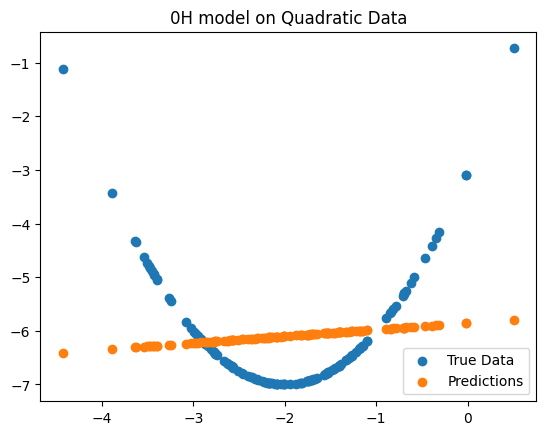


Training 1H model on quadratic data:
Epoch 100 loss: 1.842138
Epoch 200 loss: 0.896739
Epoch 300 loss: 0.693734
Epoch 400 loss: 0.543919
Epoch 500 loss: 0.421184
Epoch 600 loss: 0.324666
Epoch 700 loss: 0.253937
Epoch 800 loss: 0.205312
Epoch 900 loss: 0.173878
Epoch 1000 loss: 0.154224


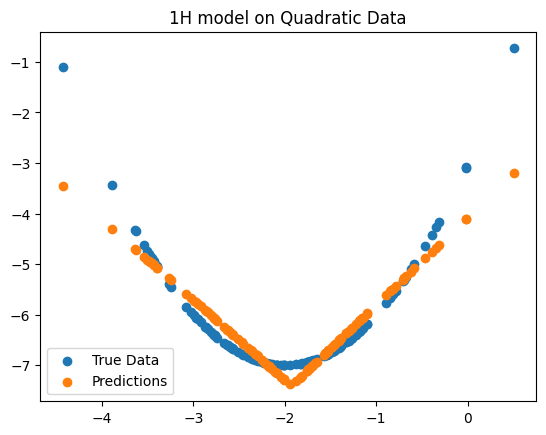


Training 2H model on quadratic data:
Epoch 100 loss: 0.875621
Epoch 200 loss: 0.498080
Epoch 300 loss: 0.256529
Epoch 400 loss: 0.531923
Epoch 500 loss: 0.319921
Epoch 600 loss: 0.183993
Epoch 700 loss: 0.108685
Epoch 800 loss: 0.077194
Epoch 900 loss: 0.052099
Epoch 1000 loss: 0.050533


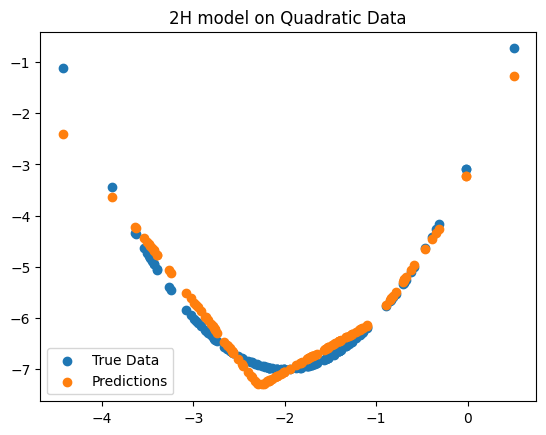

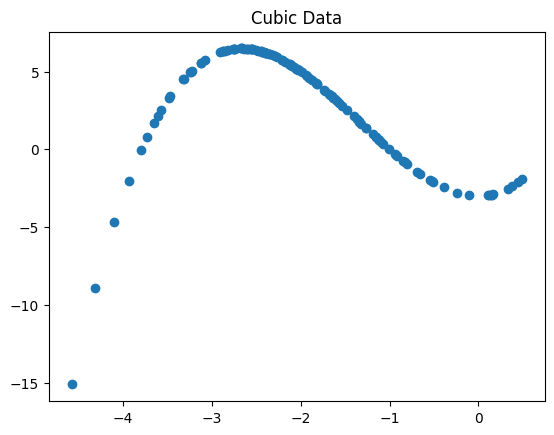


Training 0H model on cubic data:
Epoch 100 loss: 11.475407
Epoch 200 loss: 11.475062
Epoch 300 loss: 11.474906
Epoch 400 loss: 11.474836
Epoch 500 loss: 11.474806
Epoch 600 loss: 11.474792
Epoch 700 loss: 11.474786
Epoch 800 loss: 11.474783
Epoch 900 loss: 11.474781
Epoch 1000 loss: 11.474781


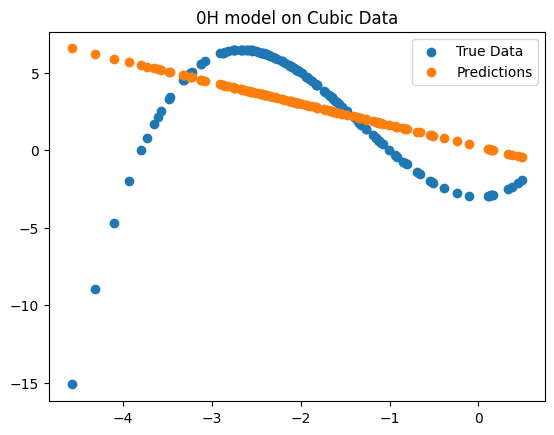


Training 1H model on cubic data:
Epoch 100 loss: 11.065259
Epoch 200 loss: 10.081029
Epoch 300 loss: 9.146365
Epoch 400 loss: 8.296001
Epoch 500 loss: 7.267084
Epoch 600 loss: 5.939032
Epoch 700 loss: 5.042837
Epoch 800 loss: 4.616409
Epoch 900 loss: 4.306010
Epoch 1000 loss: 4.031954


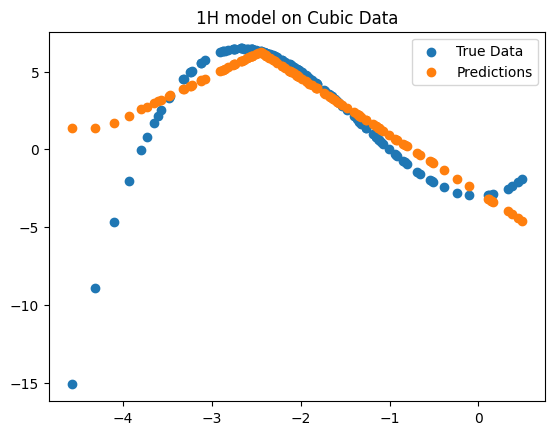


Training 2H model on cubic data:
Epoch 100 loss: 11.346468
Epoch 200 loss: 9.454874
Epoch 300 loss: 8.894958
Epoch 400 loss: 7.654537
Epoch 500 loss: 5.536271
Epoch 600 loss: 4.404495
Epoch 700 loss: 3.487779
Epoch 800 loss: 2.455208
Epoch 900 loss: 1.832620
Epoch 1000 loss: 1.338263


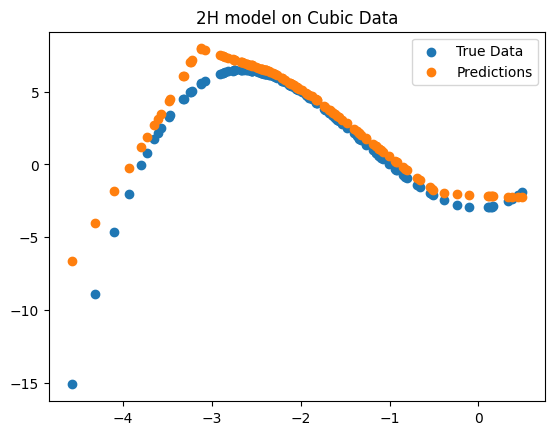

In [9]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
import numpy as np

cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if cuda else "cpu")
print("Using device:", device)

seed = 1008
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if cuda:
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def quadratic_data_generator(data_size):
    x = torch.randn(data_size, 1) - 2
    x = x.to(device)
    y = x**2 + 4*x - 3
    return x, y

def cubic_data_generator(data_size=100):
    x = torch.randn(data_size, 1) - 2
    x = x.to(device)
    y = x**3 + 4*(x**2) - 3
    return x, y

class Linear_0H(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Linear(1, 1)
    def forward(self, x):
        return self.classifier(x)

class Linear_1H(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(1, 5),
            nn.ReLU(),
            nn.Linear(5, 1)
        )
    def forward(self, x):
        return self.classifier(x)

class Linear_2H(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(1, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5, 1)
        )
    def forward(self, x):
        return self.classifier(x)


def train(model, epochs, x, y):
    model = model.to(device)
    model.train()

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        y_pred = model(x)
        loss = criterion(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1} loss: {loss.item():.6f}")

    return y_pred.detach()


x, y = quadratic_data_generator(128)
plt.scatter(x.cpu(), y.cpu())
plt.title("Quadratic Data")
plt.show()

print("\nTraining 0H model on quadratic data:")
model = Linear_0H()
y_pred = train(model, epochs=1000, x=x, y=y)
plt.scatter(x.cpu(), y.cpu(), label="True Data")
plt.scatter(x.cpu(), y_pred.cpu(), label="Predictions")
plt.title("0H model on Quadratic Data")
plt.legend()
plt.show()

print("\nTraining 1H model on quadratic data:")
model = Linear_1H()
y_pred = train(model, epochs=1000, x=x, y=y)
plt.scatter(x.cpu(), y.cpu(), label="True Data")
plt.scatter(x.cpu(), y_pred.cpu(), label="Predictions")
plt.title("1H model on Quadratic Data")
plt.legend()
plt.show()

print("\nTraining 2H model on quadratic data:")
model = Linear_2H()
y_pred = train(model, epochs=1000, x=x, y=y)
plt.scatter(x.cpu(), y.cpu(), label="True Data")
plt.scatter(x.cpu(), y_pred.cpu(), label="Predictions")
plt.title("2H model on Quadratic Data")
plt.legend()
plt.show()

x, y = cubic_data_generator(128)
plt.scatter(x.cpu(), y.cpu())
plt.title("Cubic Data")
plt.show()

print("\nTraining 0H model on cubic data:")
model = Linear_0H()
y_pred = train(model, epochs=1000, x=x, y=y)
plt.scatter(x.cpu(), y.cpu(), label="True Data")
plt.scatter(x.cpu(), y_pred.cpu(), label="Predictions")
plt.title("0H model on Cubic Data")
plt.legend()
plt.show()

print("\nTraining 1H model on cubic data:")
model = Linear_1H()
y_pred = train(model, epochs=1000, x=x, y=y)
plt.scatter(x.cpu(), y.cpu(), label="True Data")
plt.scatter(x.cpu(), y_pred.cpu(), label="Predictions")
plt.title("1H model on Cubic Data")
plt.legend()
plt.show()

print("\nTraining 2H model on cubic data:")
model = Linear_2H()
y_pred = train(model, epochs=1000, x=x, y=y)
plt.scatter(x.cpu(), y.cpu(), label="True Data")
plt.scatter(x.cpu(), y_pred.cpu(), label="Predictions")
plt.title("2H model on Cubic Data")
plt.legend()
plt.show()
